# Demographic Structure Analysis

## Project: Albania Brain Drain Analysis

This notebook analyzes Albania's age structure using the World Bank Population Estimates dataset.

The goal is to understand how Albania's demographic structure is changing, especially:

- Youth population
- Working-age population
- Elderly population
- Dependency pressure
- Population projections to 2035

This is important because brain drain can reduce the working-age population, increase dependency pressure, and create long-term economic and social challenges.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT_DIR = Path.cwd().parent
RAW_DIR = ROOT_DIR / "data" / "raw"
PROCESSED_DIR = ROOT_DIR / "data" / "processed"
VISUALS_DIR = ROOT_DIR / "visuals"
REPORTS_DIR = ROOT_DIR / "reports"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
VISUALS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print("Root:", ROOT_DIR)
print("Raw:", RAW_DIR)
print("Processed:", PROCESSED_DIR)

Root: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis
Raw: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\raw
Processed: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\processed


In [2]:
possible_population_files = list(RAW_DIR.rglob("Population-EstimatesCSV.csv"))

possible_population_files

[WindowsPath('C:/Users/mateo/Downloads/albania-brain-drain-analysis-starter(1)/albania-brain-drain-analysis/data/raw/population_estimates/Population-EstimatesCSV.csv')]

In [3]:
population_estimates_path = possible_population_files[0]

print("Using file:", population_estimates_path)

Using file: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\raw\population_estimates\Population-EstimatesCSV.csv


In [4]:
pop_est_raw = pd.read_csv(population_estimates_path)

print("Rows:", pop_est_raw.shape[0])
print("Columns:", pop_est_raw.shape[1])

pop_est_raw.head()

Rows: 49742
Columns: 95


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050
0,Africa Eastern and Southern,AFE,Age dependency ratio (% of working-age populat...,SP.POP.DPND,88.967790,89.322284,89.685064,90.122475,90.550645,91.013816,...,65.196696,64.427544,63.690560,62.989114,62.323871,61.693306,61.095171,60.527376,59.990182,59.486617
1,Africa Eastern and Southern,AFE,"Age dependency ratio, old",SP.POP.DPND.OL,5.631545,5.607333,5.585546,5.570575,5.562311,5.562341,...,6.973008,7.060297,7.157207,7.265732,7.384524,7.511798,7.644190,7.780053,7.922973,8.075579
2,Africa Eastern and Southern,AFE,"Age dependency ratio, young",SP.POP.DPND.YG,82.970097,83.310133,83.656613,84.075328,84.505689,84.987627,...,57.737055,56.910957,56.106588,55.325090,54.568021,53.835687,53.128642,52.446620,51.787006,51.150041
3,Africa Eastern and Southern,AFE,"Age population, age 00, female",SP.POP.AG00.FE.IN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Africa Eastern and Southern,AFE,"Age population, age 00, male",SP.POP.AG00.MA.IN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Filter Albania Only

In [6]:
albania_pop_est = pop_est_raw[
    pop_est_raw["Country Code"] == "ALB"
].copy()

print("Albania rows:", albania_pop_est.shape[0])

albania_pop_est[["Country Name", "Indicator Name", "Indicator Code"]].head(20)

Albania rows: 187


,Country Name,Indicator Name,Indicator Code
9350,Albania,Age dependency ratio (% of working-age populat...,SP.POP.DPND
9351,Albania,"Age dependency ratio, old",SP.POP.DPND.OL
9352,Albania,"Age dependency ratio, young",SP.POP.DPND.YG
9353,Albania,"Age population, age 00, female",SP.POP.AG00.FE.IN
9354,Albania,"Age population, age 00, male",SP.POP.AG00.MA.IN
9355,Albania,"Age population, age 01, female",SP.POP.AG01.FE.IN
9356,Albania,"Age population, age 01, male",SP.POP.AG01.MA.IN
9357,Albania,"Age population, age 02, female",SP.POP.AG02.FE.IN
9358,Albania,"Age population, age 02, male",SP.POP.AG02.MA.IN
9359,Albania,"Age population, age 03, female",SP.POP.AG03.FE.IN


## Select Important Demographic Indicators

In [7]:
demographic_indicators = {
    "SP.POP.TOTL": "population_total",
    "SP.POP.GROW": "population_growth_annual_percent",
    
    "SP.POP.0014.TO": "youth_population_0_14",
    "SP.POP.0014.TO.ZS": "youth_share_0_14_percent",
    
    "SP.POP.1564.TO": "working_age_population_15_64",
    "SP.POP.1564.TO.ZS": "working_age_share_15_64_percent",
    
    "SP.POP.65UP.TO": "elderly_population_65_plus",
    "SP.POP.65UP.TO.ZS": "elderly_share_65_plus_percent",
    
    "SP.POP.DPND": "dependency_ratio_total",
    "SP.POP.DPND.OL": "old_age_dependency_ratio",
    "SP.POP.DPND.YG": "youth_dependency_ratio",
    
    "SP.DYN.TFRT.IN": "fertility_rate",
    "SP.DYN.LE00.IN": "life_expectancy_total"
}

demographic_selected = albania_pop_est[
    albania_pop_est["Indicator Code"].isin(demographic_indicators.keys())
].copy()

demographic_selected[["Indicator Name", "Indicator Code"]]

,Indicator Name,Indicator Code
9350,Age dependency ratio (% of working-age populat...,SP.POP.DPND
9351,"Age dependency ratio, old",SP.POP.DPND.OL
9352,"Age dependency ratio, young",SP.POP.DPND.YG
9407,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN
9410,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN
9437,Population ages 0-14 (% of total population),SP.POP.0014.TO.ZS
9442,"Population ages 0-14, total",SP.POP.0014.TO
9455,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS
9460,"Population ages 15-64, total",SP.POP.1564.TO
9497,Population ages 65 and above (% of total popul...,SP.POP.65UP.TO.ZS


## Convert from Wide to Long Format

In [8]:
id_columns = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]

year_columns = [
    col for col in demographic_selected.columns
    if col.isdigit()
]

demographic_long = demographic_selected.melt(
    id_vars=id_columns,
    value_vars=year_columns,
    var_name="year",
    value_name="value"
)

demographic_long["year"] = demographic_long["year"].astype(int)
demographic_long["value"] = pd.to_numeric(demographic_long["value"], errors="coerce")

demographic_long["indicator_short_name"] = demographic_long["Indicator Code"].map(
    demographic_indicators
)

demographic_long = demographic_long.rename(columns={
    "Country Name": "country_name",
    "Country Code": "country_code",
    "Indicator Name": "indicator_name",
    "Indicator Code": "indicator_code"
})

demographic_long = demographic_long[
    [
        "country_name",
        "country_code",
        "indicator_name",
        "indicator_code",
        "indicator_short_name",
        "year",
        "value"
    ]
]

demographic_long.head()

,country_name,country_code,indicator_name,indicator_code,indicator_short_name,year,value
0,Albania,ALB,Age dependency ratio (% of working-age populat...,SP.POP.DPND,dependency_ratio_total,1960,87.482447
1,Albania,ALB,"Age dependency ratio, old",SP.POP.DPND.OL,old_age_dependency_ratio,1960,10.286479
2,Albania,ALB,"Age dependency ratio, young",SP.POP.DPND.YG,youth_dependency_ratio,1960,77.195967
3,Albania,ALB,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,fertility_rate,1960,6.383000
4,Albania,ALB,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,life_expectancy_total,1960,56.413000


## Filter Years 2000 to 2035

In [9]:
demographic_clean = demographic_long[
    (demographic_long["year"] >= 2000) &
    (demographic_long["year"] <= 2035)
].copy()

demographic_clean = demographic_clean.dropna(subset=["value"])

demographic_clean = demographic_clean.sort_values(
    ["indicator_short_name", "year"]
)

print("Rows:", demographic_clean.shape[0])
print("Year range:", demographic_clean["year"].min(), "-", demographic_clean["year"].max())

demographic_clean.head()

Rows: 439
Year range: 2000 - 2035


,country_name,country_code,indicator_name,indicator_code,indicator_short_name,year,value
520,Albania,ALB,Age dependency ratio (% of working-age populat...,SP.POP.DPND,dependency_ratio_total,2000,58.597729
533,Albania,ALB,Age dependency ratio (% of working-age populat...,SP.POP.DPND,dependency_ratio_total,2001,57.835171
546,Albania,ALB,Age dependency ratio (% of working-age populat...,SP.POP.DPND,dependency_ratio_total,2002,56.736702
559,Albania,ALB,Age dependency ratio (% of working-age populat...,SP.POP.DPND,dependency_ratio_total,2003,55.613998
572,Albania,ALB,Age dependency ratio (% of working-age populat...,SP.POP.DPND,dependency_ratio_total,2004,54.521123


## Save Clean Demographic Dataset

In [11]:
demographic_clean_path = PROCESSED_DIR / "demographic_structure_clean.csv"

demographic_clean.to_csv(demographic_clean_path, index=False)

print("Saved:", demographic_clean_path)

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\processed\demographic_structure_clean.csv


## Create Wide Demographic Dataset

In [12]:
demographic_wide = (
    demographic_clean
    .pivot_table(
        index="year",
        columns="indicator_short_name",
        values="value",
        aggfunc="first"
    )
    .reset_index()
)

demographic_wide.columns.name = None

demographic_wide.head()

,year,dependency_ratio_total,elderly_population_65_plus,elderly_share_65_plus_percent,fertility_rate,life_expectancy_total,old_age_dependency_ratio,population_growth_annual_percent,population_total,working_age_population_15_64,working_age_share_15_64_percent,youth_dependency_ratio,youth_population_0_14,youth_share_0_14_percent
0,2000,58.597729,226447.0,7.330691,2.217,74.826,11.626308,-0.637357,3089027.0,1947712.0,63.052606,46.971421,914868.0,29.616703
1,2001,57.835171,232750.0,7.605791,2.141,75.083,12.004594,-0.938470,3060173.0,1938841.0,63.357220,45.830576,888582.0,29.036989
2,2002,56.736702,241470.0,7.914429,2.002,75.299,12.404814,-0.299877,3051010.0,1946583.0,63.801254,44.331888,862957.0,28.284316
3,2003,55.613998,250494.0,8.240965,2.006,75.557,12.824111,-0.374149,3039616.0,1953305.0,64.261587,42.789887,835817.0,27.497448
4,2004,54.521123,259893.0,8.586009,1.889,75.951,13.267185,-0.417931,3026939.0,1958916.0,64.716058,41.253938,808130.0,26.697933


In [13]:
demographic_wide_path = PROCESSED_DIR / "demographic_structure_wide.csv"

demographic_wide.to_csv(demographic_wide_path, index=False)

print("Saved:", demographic_wide_path)

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\processed\demographic_structure_wide.csv


## Create Extra Demographic Features

In [14]:
demographic_wide["youth_to_working_age_ratio"] = (
    demographic_wide["youth_population_0_14"] /
    demographic_wide["working_age_population_15_64"]
)

demographic_wide["elderly_to_working_age_ratio"] = (
    demographic_wide["elderly_population_65_plus"] /
    demographic_wide["working_age_population_15_64"]
)

demographic_wide["working_age_population_change"] = (
    demographic_wide["working_age_population_15_64"].diff()
)

demographic_wide["elderly_population_change"] = (
    demographic_wide["elderly_population_65_plus"].diff()
)

demographic_wide.head()

,year,dependency_ratio_total,elderly_population_65_plus,elderly_share_65_plus_percent,fertility_rate,life_expectancy_total,old_age_dependency_ratio,population_growth_annual_percent,population_total,working_age_population_15_64,working_age_share_15_64_percent,youth_dependency_ratio,youth_population_0_14,youth_share_0_14_percent,youth_to_working_age_ratio,elderly_to_working_age_ratio,working_age_population_change,elderly_population_change
0,2000,58.597729,226447.0,7.330691,2.217,74.826,11.626308,-0.637357,3089027.0,1947712.0,63.052606,46.971421,914868.0,29.616703,0.469714,0.116263,NaN,NaN
1,2001,57.835171,232750.0,7.605791,2.141,75.083,12.004594,-0.938470,3060173.0,1938841.0,63.357220,45.830576,888582.0,29.036989,0.458306,0.120046,-8871.0,6303.0
2,2002,56.736702,241470.0,7.914429,2.002,75.299,12.404814,-0.299877,3051010.0,1946583.0,63.801254,44.331888,862957.0,28.284316,0.443319,0.124048,7742.0,8720.0
3,2003,55.613998,250494.0,8.240965,2.006,75.557,12.824111,-0.374149,3039616.0,1953305.0,64.261587,42.789887,835817.0,27.497448,0.427899,0.128241,6722.0,9024.0
4,2004,54.521123,259893.0,8.586009,1.889,75.951,13.267185,-0.417931,3026939.0,1958916.0,64.716058,41.253938,808130.0,26.697933,0.412539,0.132672,5611.0,9399.0


In [15]:
demographic_wide.to_csv(
    PROCESSED_DIR / "demographic_structure_wide.csv",
    index=False
)

print("Updated demographic_structure_wide.csv")

Updated demographic_structure_wide.csv


## Merge Demographics with Master Dataset

In [16]:
master_path = PROCESSED_DIR / "master_analysis_dataset.csv"

master = pd.read_csv(master_path)

master_with_demographics = master.merge(
    demographic_wide,
    on="year",
    how="left",
    suffixes=("", "_demographic")
)

master_with_demographics.head()

,year,fdi_percent_gdp,gdp_current_usd,gdp_growth_annual_percent,gdp_per_capita_current_usd,net_migration,population_growth_annual_percent,population_total,remittances_percent_gdp,unemployment_total_percent,...,population_total_demographic,working_age_population_15_64,working_age_share_15_64_percent,youth_dependency_ratio,youth_population_0_14,youth_share_0_14_percent,youth_to_working_age_ratio,elderly_to_working_age_ratio,working_age_population_change,elderly_population_change
0,2000,3.989321,3.584570e+09,7.462859,1160.420471,-60531.0,-0.637357,3089027.0,16.677034,19.023,...,3089027.0,1947712.0,63.052606,46.971421,914868.0,29.616703,0.469714,0.116263,NaN,NaN
1,2001,5.107089,4.059064e+09,8.863731,1326.416524,-48070.0,-0.938470,3060173.0,17.228110,18.570,...,3060173.0,1938841.0,63.357220,45.830576,888582.0,29.036989,0.458306,0.120046,-8871.0,6303.0
2,2002,2.990031,4.515003e+09,4.628396,1479.838846,-45178.0,-0.299877,3051010.0,16.247386,17.891,...,3051010.0,1946583.0,63.801254,44.331888,862957.0,28.284316,0.443319,0.124048,7742.0,8720.0
3,2003,3.068687,5.801712e+09,5.333264,1908.699007,-48517.0,-0.374149,3039616.0,15.318730,16.985,...,3039616.0,1953305.0,64.261587,42.789887,835817.0,27.497448,0.427899,0.128241,6722.0,9024.0
4,2004,4.607823,7.406646e+09,5.266262,2446.909499,-48654.0,-0.417931,3026939.0,15.670685,16.306,...,3026939.0,1958916.0,64.716058,41.253938,808130.0,26.697933,0.412539,0.132672,5611.0,9399.0


In [17]:
master_demo_path = PROCESSED_DIR / "master_analysis_dataset_with_demographics.csv"

master_with_demographics.to_csv(master_demo_path, index=False)

print("Saved:", master_demo_path)

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\data\processed\master_analysis_dataset_with_demographics.csv


## Youth, Working-Age, and Elderly Population Chart

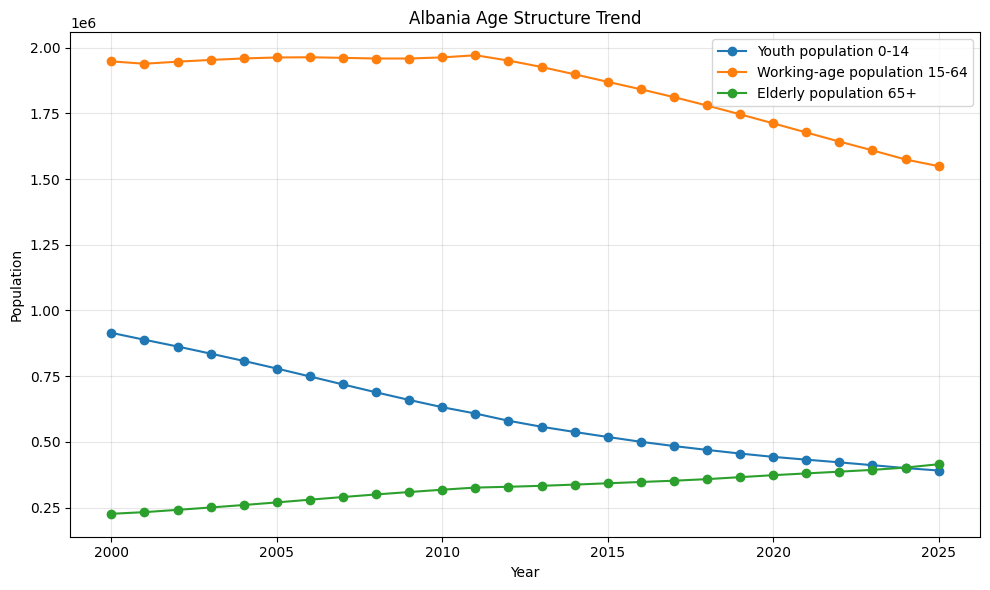

In [18]:
historical_demo = demographic_wide[
    demographic_wide["year"] <= 2025
].copy()

plt.figure(figsize=(10, 6))

plt.plot(
    historical_demo["year"],
    historical_demo["youth_population_0_14"],
    marker="o",
    label="Youth population 0-14"
)

plt.plot(
    historical_demo["year"],
    historical_demo["working_age_population_15_64"],
    marker="o",
    label="Working-age population 15-64"
)

plt.plot(
    historical_demo["year"],
    historical_demo["elderly_population_65_plus"],
    marker="o",
    label="Elderly population 65+"
)

plt.title("Albania Age Structure Trend")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(VISUALS_DIR / "age_structure_trend.png", dpi=300)
plt.show()

## Population Shares Chart

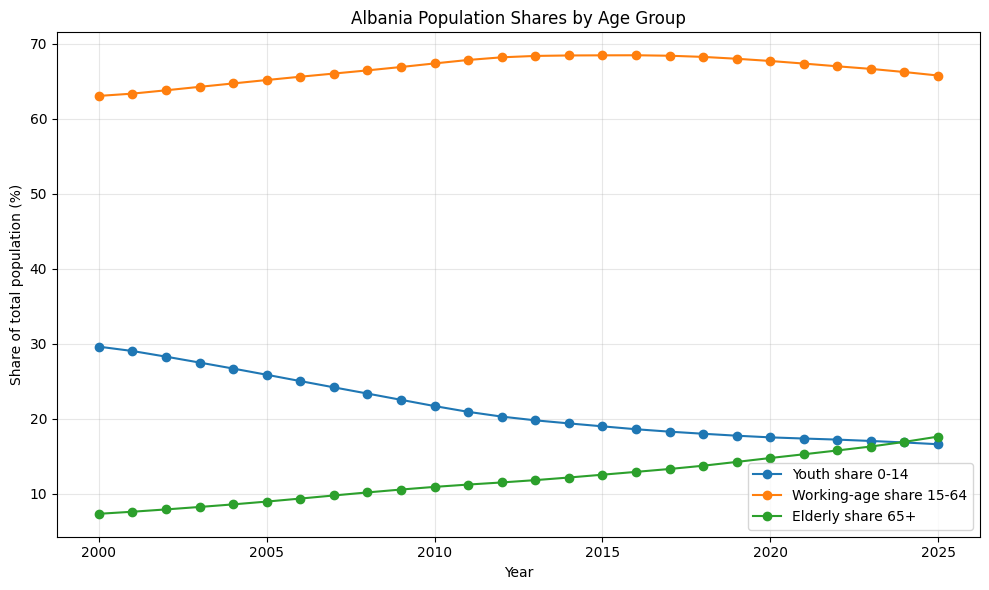

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    historical_demo["year"],
    historical_demo["youth_share_0_14_percent"],
    marker="o",
    label="Youth share 0-14"
)

plt.plot(
    historical_demo["year"],
    historical_demo["working_age_share_15_64_percent"],
    marker="o",
    label="Working-age share 15-64"
)

plt.plot(
    historical_demo["year"],
    historical_demo["elderly_share_65_plus_percent"],
    marker="o",
    label="Elderly share 65+"
)

plt.title("Albania Population Shares by Age Group")
plt.xlabel("Year")
plt.ylabel("Share of total population (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(VISUALS_DIR / "age_group_shares_trend.png", dpi=300)
plt.show()

## Dependency Ratio Chart

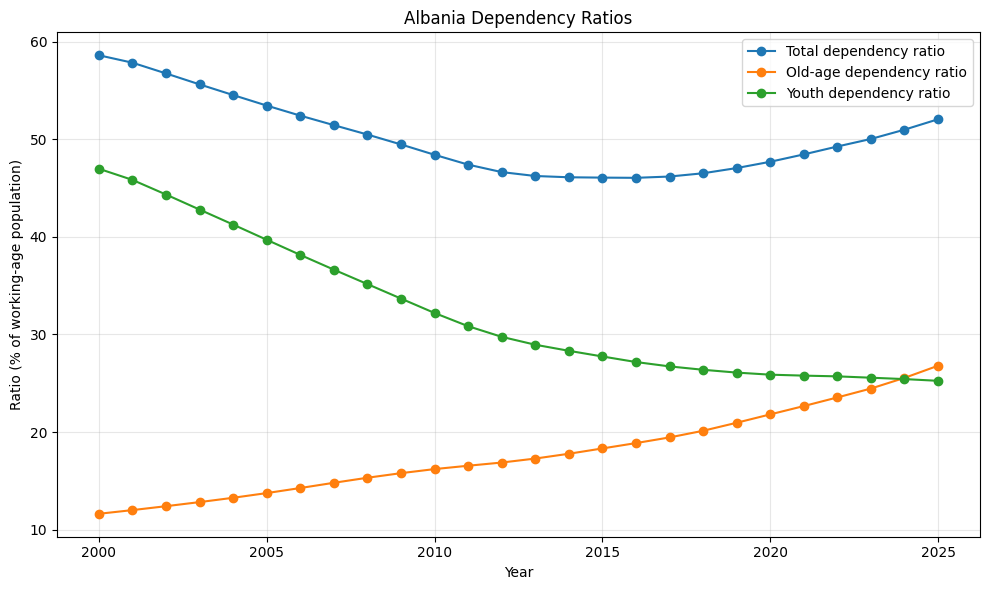

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(
    historical_demo["year"],
    historical_demo["dependency_ratio_total"],
    marker="o",
    label="Total dependency ratio"
)

plt.plot(
    historical_demo["year"],
    historical_demo["old_age_dependency_ratio"],
    marker="o",
    label="Old-age dependency ratio"
)

plt.plot(
    historical_demo["year"],
    historical_demo["youth_dependency_ratio"],
    marker="o",
    label="Youth dependency ratio"
)

plt.title("Albania Dependency Ratios")
plt.xlabel("Year")
plt.ylabel("Ratio (% of working-age population)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(VISUALS_DIR / "dependency_ratios_trend.png", dpi=300)
plt.show()

## Projection to 2035 Chart

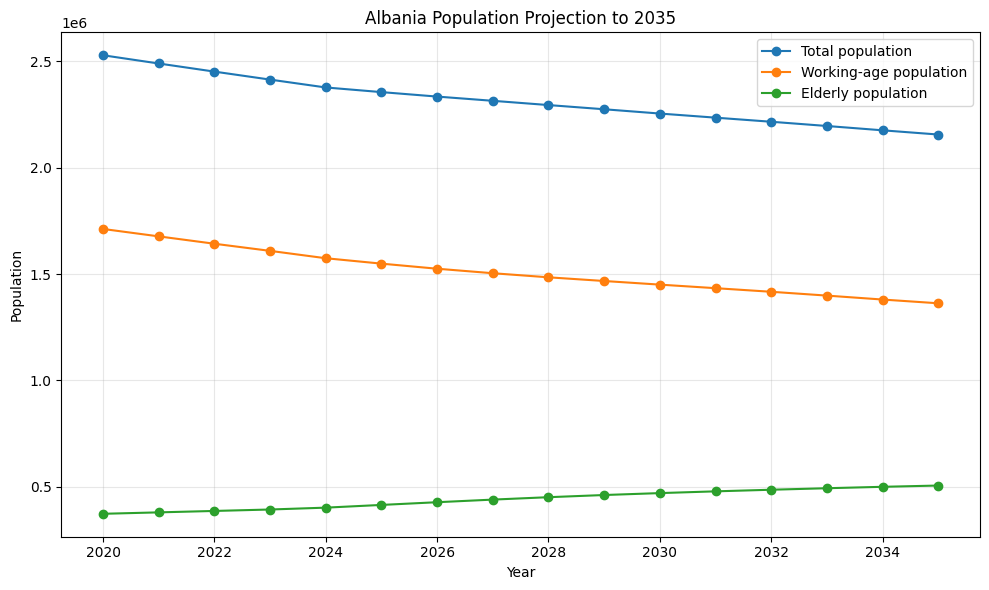

In [22]:
projection_demo = demographic_wide[
    (demographic_wide["year"] >= 2020) &
    (demographic_wide["year"] <= 2035)
].copy()

plt.figure(figsize=(10, 6))

plt.plot(
    projection_demo["year"],
    projection_demo["population_total"],
    marker="o",
    label="Total population"
)

plt.plot(
    projection_demo["year"],
    projection_demo["working_age_population_15_64"],
    marker="o",
    label="Working-age population"
)

plt.plot(
    projection_demo["year"],
    projection_demo["elderly_population_65_plus"],
    marker="o",
    label="Elderly population"
)

plt.title("Albania Population Projection to 2035")
plt.xlabel("Year")
plt.ylabel("Population")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(VISUALS_DIR / "population_projection_2035_from_estimates.png", dpi=300)
plt.show()

## Calculate Key Demographic Changes

In [23]:
def get_value(df, year, column):
    value = df.loc[df["year"] == year, column]
    if value.empty:
        return np.nan
    return value.iloc[0]


summary_year_start = 2000
summary_year_latest = historical_demo["year"].max()
summary_year_projection = 2035

key_demographic_changes = {
    "population_2000": get_value(demographic_wide, summary_year_start, "population_total"),
    "population_latest": get_value(demographic_wide, summary_year_latest, "population_total"),
    "population_2035": get_value(demographic_wide, summary_year_projection, "population_total"),
    
    "working_age_2000": get_value(demographic_wide, summary_year_start, "working_age_population_15_64"),
    "working_age_latest": get_value(demographic_wide, summary_year_latest, "working_age_population_15_64"),
    "working_age_2035": get_value(demographic_wide, summary_year_projection, "working_age_population_15_64"),
    
    "elderly_2000": get_value(demographic_wide, summary_year_start, "elderly_population_65_plus"),
    "elderly_latest": get_value(demographic_wide, summary_year_latest, "elderly_population_65_plus"),
    "elderly_2035": get_value(demographic_wide, summary_year_projection, "elderly_population_65_plus"),
    
    "youth_2000": get_value(demographic_wide, summary_year_start, "youth_population_0_14"),
    "youth_latest": get_value(demographic_wide, summary_year_latest, "youth_population_0_14"),
    "youth_2035": get_value(demographic_wide, summary_year_projection, "youth_population_0_14"),
}

key_demographic_changes_df = pd.DataFrame(
    list(key_demographic_changes.items()),
    columns=["metric", "value"]
)

key_demographic_changes_df

,metric,value
0,population_2000,3089027.0
1,population_latest,2355297.0
2,population_2035,2155920.0
3,working_age_2000,1947712.0
4,working_age_latest,1549119.0
5,working_age_2035,1362789.0
6,elderly_2000,226447.0
7,elderly_latest,415053.0
8,elderly_2035,506156.0
9,youth_2000,914868.0


In [24]:
key_demographic_changes_df.to_csv(
    PROCESSED_DIR / "key_demographic_changes.csv",
    index=False
)

print("Saved key_demographic_changes.csv")

Saved key_demographic_changes.csv


## Generate Demographic Summary Report

In [25]:
def percent_change(new, old):
    if pd.isna(new) or pd.isna(old) or old == 0:
        return np.nan
    return ((new - old) / old) * 100


population_change_2000_latest = percent_change(
    key_demographic_changes["population_latest"],
    key_demographic_changes["population_2000"]
)

population_change_2000_2035 = percent_change(
    key_demographic_changes["population_2035"],
    key_demographic_changes["population_2000"]
)

working_age_change_2000_latest = percent_change(
    key_demographic_changes["working_age_latest"],
    key_demographic_changes["working_age_2000"]
)

working_age_change_2000_2035 = percent_change(
    key_demographic_changes["working_age_2035"],
    key_demographic_changes["working_age_2000"]
)

elderly_change_2000_latest = percent_change(
    key_demographic_changes["elderly_latest"],
    key_demographic_changes["elderly_2000"]
)

elderly_change_2000_2035 = percent_change(
    key_demographic_changes["elderly_2035"],
    key_demographic_changes["elderly_2000"]
)


report_lines = []

report_lines.append("# Demographic Structure Analysis Report")
report_lines.append("")
report_lines.append("## Project")
report_lines.append("")
report_lines.append("Albania’s Brain Drain: A Data-Driven Analysis of Migration, Employment and Economic Development")
report_lines.append("")
report_lines.append("## Purpose")
report_lines.append("")
report_lines.append("This report summarizes Albania's demographic structure using the World Bank Population Estimates dataset.")
report_lines.append("")
report_lines.append("The analysis focuses on youth population, working-age population, elderly population, dependency pressure, and projections to 2035.")
report_lines.append("")

report_lines.append("## Key Demographic Indicators")
report_lines.append("")
report_lines.append(f"- Population in 2000: {key_demographic_changes['population_2000']:,.0f}")
report_lines.append(f"- Latest available population year: {summary_year_latest}")
report_lines.append(f"- Latest available population: {key_demographic_changes['population_latest']:,.0f}")
report_lines.append(f"- Projected population in 2035: {key_demographic_changes['population_2035']:,.0f}")
report_lines.append("")

report_lines.append("## Population Change")
report_lines.append("")
report_lines.append(f"- Population change from 2000 to latest available year: {population_change_2000_latest:.2f}%")
report_lines.append(f"- Population change from 2000 to 2035 projection: {population_change_2000_2035:.2f}%")
report_lines.append("")

report_lines.append("## Working-Age Population")
report_lines.append("")
report_lines.append(f"- Working-age population in 2000: {key_demographic_changes['working_age_2000']:,.0f}")
report_lines.append(f"- Latest working-age population: {key_demographic_changes['working_age_latest']:,.0f}")
report_lines.append(f"- Projected working-age population in 2035: {key_demographic_changes['working_age_2035']:,.0f}")
report_lines.append(f"- Working-age population change from 2000 to latest year: {working_age_change_2000_latest:.2f}%")
report_lines.append(f"- Working-age population change from 2000 to 2035 projection: {working_age_change_2000_2035:.2f}%")
report_lines.append("")

report_lines.append("## Elderly Population")
report_lines.append("")
report_lines.append(f"- Elderly population in 2000: {key_demographic_changes['elderly_2000']:,.0f}")
report_lines.append(f"- Latest elderly population: {key_demographic_changes['elderly_latest']:,.0f}")
report_lines.append(f"- Projected elderly population in 2035: {key_demographic_changes['elderly_2035']:,.0f}")
report_lines.append(f"- Elderly population change from 2000 to latest year: {elderly_change_2000_latest:.2f}%")
report_lines.append(f"- Elderly population change from 2000 to 2035 projection: {elderly_change_2000_2035:.2f}%")
report_lines.append("")

report_lines.append("## Interpretation")
report_lines.append("")
report_lines.append("The demographic structure analysis helps explain why brain drain matters beyond migration numbers.")
report_lines.append("")
report_lines.append("If the working-age population declines while the elderly population increases, Albania may face stronger pressure on the labour market, pension system, healthcare system, and long-term economic growth.")
report_lines.append("")
report_lines.append("Youth and working-age migration can reduce the future labour force and create skill shortages, especially if educated or economically active people leave the country.")
report_lines.append("")

report_lines.append("## Limitations")
report_lines.append("")
report_lines.append("- The projection values are based on population estimates and should not be interpreted as guaranteed future outcomes.")
report_lines.append("- Population structure can change due to migration policy, fertility, mortality, economic conditions, and return migration.")
report_lines.append("- Age-group indicators are useful for demographic risk analysis, but they do not directly identify education level or skill level of migrants.")
report_lines.append("")

report_lines.append("## Visuals Created")
report_lines.append("")
report_lines.append("- age_structure_trend.png")
report_lines.append("- age_group_shares_trend.png")
report_lines.append("- dependency_ratios_trend.png")
report_lines.append("- population_projection_2035_from_estimates.png")
report_lines.append("")

demographic_report_path = REPORTS_DIR / "demographic_structure_report.md"

with open(demographic_report_path, "w", encoding="utf-8") as f:
    f.write("\n".join(report_lines))

print("Saved:", demographic_report_path)

Saved: C:\Users\mateo\Downloads\albania-brain-drain-analysis-starter(1)\albania-brain-drain-analysis\reports\demographic_structure_report.md


## Check Outputs

In [26]:
print("Processed demographic files:")
for file in PROCESSED_DIR.glob("*demographic*"):
    print("-", file.name)

print("\nDemographic visuals:")
for file in VISUALS_DIR.glob("*age*"):
    print("-", file.name)

for file in VISUALS_DIR.glob("*dependency*"):
    print("-", file.name)

for file in VISUALS_DIR.glob("*projection*"):
    print("-", file.name)

print("\nReports:")
for file in REPORTS_DIR.glob("*demographic*"):
    print("-", file.name)

Processed demographic files:
- demographic_structure_clean.csv
- demographic_structure_wide.csv
- key_demographic_changes.csv
- master_analysis_dataset_with_demographics.csv

Demographic visuals:
- age_group_shares_trend.png
- age_structure_trend.png
- dependency_ratios_trend.png
- population_projection_2035_from_estimates.png

Reports:
- demographic_structure_report.md
